# 5-B. SHAP RFE — SHAP 중요도 기반 재귀적 피처 제거 실험 (Self-Contained)

이 노트북은 외부 스크립트(`src/fs_core.py`, `config/fs_config.py` 등)의 의존성을 완전히 제거하고, 
노트북 내부에서 데이터 로드, 교차 검증 학습, SHAP 중요도 계산, 그리고 피처 제거 실험까지 독자적으로 실행할 수 있도록 통합 구성되었습니다.

### 💡 학습 시간 단축 가이드 (5-Fold CV vs. 단일 Split)
- 5-Fold CV는 모델을 폴드당 1번씩 총 5번 훈련하므로, 단일 Validation 학습 대비 **산술적으로 5배의 시간**이 더 소요됩니다.
- 피처를 하나씩 누적하여 제거하는 시뮬레이션 특성상 연산 부하가 매우 큽니다.
- **팁**: 빠른 피처 탐색이 필요할 때는 `LocalConfig.CV_N_SPLITS = 1`로 설정하여 **단일 Validation 세트 검증**으로 빠르게 구동하고, 최종 정밀 검증 시에만 `CV_N_SPLITS = 5`로 올리는 방식을 권장합니다.

In [1]:
# ── Cell 1: 라이브러리 임포트 및 독립 설정 구역 ───────────────────────
import os
import sys
import json
import warnings
from typing import Optional

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

# GPU 가속 지원 여부 동적 체크
import lightgbm as lgb
def check_gpu():
    try:
        lgb.train({'device': 'gpu', 'verbose': -1},
                  lgb.Dataset(np.zeros((1, 1)), label=[0]))
        return True
    except:
        return False

# 한글 폰트 설정
def _set_korean_font():
    candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]
    for name in candidates:
        if any(name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

_set_korean_font()

# ── [독립 설정 클래스] ────────────────────────────────────────
class LocalConfig:
    DATA_ROOT = "../data2"      # 데이터 루트 폴더 (data2)
    TRAIN_PATH = f"{DATA_ROOT}/05_feature_selection/fs_train_filtered.parquet"
    VALIDATION_PATH  = f"{DATA_ROOT}/05_feature_selection/fs_validation_filtered.parquet"
    FEATURE_GROUP_PATH = "../config/json/feature_groups.json"  # 프로젝트 루트 기준

    TARGET_COL = "failure"
    SEED = 42

    # LightGBM 하이퍼파라미터
    LGBM_PARAMS = {
        "objective":              "binary",
        "importance_type":        "gain",
        # "class_weight":           "balanced",
        "max_depth":              7,
        "num_leaves":             60,
        "n_estimators":           300,
        "learning_rate":          0.03,
        "device":                 "gpu" if check_gpu() else "cpu",
        "random_state":           SEED,
        "bagging_seed":           SEED,
        "feature_fraction_seed":  SEED,
        "data_random_seed":       SEED,
        "n_jobs":                 -1,
        "verbose":                -1,
    }

    SHAP_SAMPLE_N = 3000



c:\Workspace\06_ML_projdect\26_1_COIN\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── 디스크 레벨 평가 헬퍼 함수 (Self-Contained) ───────────────────────
def get_rolling_n_largest(probs: np.ndarray, n: int, W: int) -> float:
    """확률 배열 probs에서 크기가 W인 모든 슬라이딩 윈도우 중 n번째로 큰 값의 최댓값을 반환"""
    if len(probs) < n:
        return 0.0
    if len(probs) < W:
        return np.sort(probs)[-n]
    try:
        from numpy.lib.stride_tricks import sliding_window_view
        windows = sliding_window_view(probs, W)
        return np.partition(windows, -n, axis=1)[:, -n].max()
    except Exception:
        max_val = 0.0
        for i in range(len(probs) - W + 1):
            window = probs[i:i+W]
            val = np.partition(window, -n)[-n]
            if val > max_val:
                max_val = val
        return max_val

def prepare_disk_level_data(
    df: pd.DataFrame,
    y_prob: np.ndarray,
    target_col: str = "failure",
    serial_col: str = "serial_number",
    date_col: str = "date",
) -> tuple[list[dict], int, int]:
    """Base Serial 단위로 고장/정상 여부 및 예측 확률을 날짜 순서로 그룹화하여 반환."""
    df = df.copy()
    df["y_prob"] = np.asarray(y_prob)
    df["base_serial"] = df[serial_col].str.replace(r'_\d+$', '', regex=True)
    df = df.sort_values(["base_serial", date_col])
    
    disks_data = []
    for base_serial, grp in df.groupby("base_serial"):
        disks_data.append({
            "base_serial": base_serial,
            "is_failed": int(grp[target_col].max()),
            "probs": grp["y_prob"].values,
            "dates": grp[date_col].values,
            "failures": grp[target_col].values
        })
        
    n_failed = sum(d["is_failed"] for d in disks_data)
    n_normal = len(disks_data) - n_failed
    return disks_data, n_failed, n_normal

def run_disk_level_grid_search(
    disks_data: list[dict],
    thresholds: np.ndarray,
    min_alarms_list: list[int],
    n_failed_disks: int,
    n_normal_disks: int,
    log_dir: str | None = None,
    window_size: int | None = None,
    horizon: int | None = None,
) -> pd.DataFrame:
    """그리드 서치를 벡터화하여 고속 실행하며, window_size에 따른 롤링 윈도우 알림 제약을 지원"""
    import os
    import pandas as pd
    import time
    is_failed_arr = np.array([d['is_failed'] for d in disks_data], dtype=bool)
    nth_probs_matrix = np.zeros((len(disks_data), len(min_alarms_list)))
    
    failed_disks_days = []
    failed_disks_probs = []
    for disk in disks_data:
        if disk['is_failed'] == 1:
            dates = pd.Series(pd.to_datetime(disk['dates']))
            days = (dates.iloc[-1] - dates).dt.days.values
            failed_disks_days.append(days)
            failed_disks_probs.append(disk['probs'])
    
    for idx, disk in enumerate(disks_data):
        probs = disk['probs']
        for n_idx, n in enumerate(min_alarms_list):
            if len(probs) < n:
                nth_probs_matrix[idx, n_idx] = 0.0
            elif window_size is None or window_size <= 0:
                probs_desc = np.sort(probs)[::-1]
                nth_probs_matrix[idx, n_idx] = probs_desc[n - 1]
            else:
                nth_probs_matrix[idx, n_idx] = get_rolling_n_largest(probs, n, window_size)
                
    grid_results = []
    total_combinations = len(min_alarms_list) * len(thresholds)
    count = 0
    t_grid = time.perf_counter()
    
    for n_idx, n in enumerate(min_alarms_list):
        nth_p = nth_probs_matrix[:, n_idx]
        for T in thresholds:
            count += 1
            is_alarmed = (nth_p >= T)
            fps = np.sum(is_alarmed & ~is_failed_arr)
            
            if horizon is not None:
                tps = 0
                for d_days, d_probs in zip(failed_disks_days, failed_disks_probs):
                    idx = np.where(d_probs >= T)[0]
                    if len(idx) >= n:
                        if d_days[idx[n-1]] <= horizon:
                            tps += 1
            else:
                tps = np.sum(is_alarmed & is_failed_arr)
            
            recall = tps / n_failed_disks if n_failed_disks > 0 else 0.0
            far = fps / n_normal_disks if n_normal_disks > 0 else 0.0
            grid_results.append({
                'threshold': T,
                'min_alarms': n,
                'recall': recall,
                'far': far,
                'tps': tps,
                'fps': fps
            })
            
            if count % 500 == 0 or count == total_combinations:
                elapsed = time.perf_counter() - t_grid
                pct = 100.0 * count / total_combinations
                print(f'  ... {count:,}/{total_combinations:,} ({pct:.1f}%) - {elapsed:.1f}s')
                
    df_grid = pd.DataFrame(grid_results)
    return df_grid

def evaluate_detailed_disk_point(
    disks_data: list[dict],
    T: float,
    n: int,
    n_failed_disks: int,
    n_normal_disks: int,
    far_cap: float | None = None,
    window_size: int | None = None,
    horizon: int | None = None,
) -> dict:
    """선택된 단일 운영점에서 세부 지표(Brier Score, 리드타임, Persistence 등) 평가"""
    tps = 0
    fns = 0
    fps = 0
    tns = 0
    lead_times = []
    persistences = []
    fw_hits = []
    density_windows = []
    density_befores = []
    consec_lengths = []
    alert_burdens = []
    
    for disk in disks_data:
        probs = disk['probs']
        failures = disk['failures']
        is_failed = disk['is_failed']
        
        y_pred = (probs >= T).astype(int)
        total_alarms = y_pred.sum()
        
        if window_size is not None and window_size > 0:
            rolling_alarms = pd.Series(y_pred).rolling(window=window_size, min_periods=1).sum().values
            is_alarmed = int((rolling_alarms >= n).any())
        else:
            is_alarmed = int(total_alarms >= n)
        
        max_consec = 0; curr_consec = 0
        for val in y_pred:
            if val == 1:
                curr_consec += 1
                if curr_consec > max_consec:
                    max_consec = curr_consec
            else:
                curr_consec = 0
        consec_lengths.append(max_consec)
        alert_burdens.append(total_alarms)
        
        if is_failed == 1:
            if is_alarmed == 1:
                if window_size is not None and window_size > 0:
                    trigger_idx = np.where(rolling_alarms >= n)[0][0]
                else:
                    trigger_idx = np.where(y_pred == 1)[0][n - 1]
                trigger_date = pd.to_datetime(disk['dates'][trigger_idx])
                last_date = pd.to_datetime(disk['dates'][-1])
                
                lead_time = (last_date - trigger_date).days
                
                if horizon is not None and lead_time > horizon:
                    fns += 1
                    fw_hits.append(0)
                else:
                    tps += 1
                    lead_times.append(lead_time)
                    
                    alarms_after = y_pred[trigger_idx:].sum()
                    days_after = len(y_pred[trigger_idx:])
                    persistences.append(alarms_after / days_after if days_after > 0 else 0.0)
                    fw_hits.append(1 if y_pred[failures == 1].sum() > 0 else 0)
            else:
                fns += 1
                fw_hits.append(0)
                
            n_fw_rows = (failures == 1).sum()
            n_non_fw_rows = (failures == 0).sum()
            density_windows.append(y_pred[failures == 1].sum() / n_fw_rows if n_fw_rows > 0 else 0.0)
            density_befores.append(y_pred[failures == 0].sum() / n_non_fw_rows if n_non_fw_rows > 0 else 0.0)
        else:
            if is_alarmed == 1:
                fps += 1
            else:
                tns += 1
                
    mean_density_window = np.mean(density_windows) if density_windows else 0.0
    mean_density_before = np.mean(density_befores) if density_befores else 0.0
    max_probs = [np.max(d['probs']) for d in disks_data]
    y_true_disks = [d['is_failed'] for d in disks_data]
    
    res = {
        'threshold': T,
        'min_alarms': n,
        'recall': tps / n_failed_disks if n_failed_disks > 0 else 0.0,
        'far': fps / n_normal_disks if n_normal_disks > 0 else 0.0,
        'precision': tps / (tps + fps) if (tps + fps) > 0 else 0.0,
        'lead_time': np.mean(lead_times) if lead_times else 0.0,
        'persistence': np.mean(persistences) if persistences else 0.0,
        'fw_hit_rate': np.mean(fw_hits) if fw_hits else 0.0,
        'density_ratio': mean_density_window / mean_density_before if mean_density_before > 0 else 0.0,
        'consec_len': np.mean(consec_lengths),
        'alert_burden': np.mean(alert_burdens),
        'calibration': np.mean((np.array(max_probs) - np.array(y_true_disks))**2)
    }
    if far_cap is not None:
        res['far_cap'] = far_cap
    return res

# ── Cell 2: 독립 검증 학습 및 SHAP 추출 함수 정의 ─────────────────
def train_evaluate(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series
) -> dict:
    """
    Train 데이터 전체로 학습하고 Validation 데이터로 디스크 단위 롤링 평가 결과의 PR-AUC를 계산하여 반환합니다.
    """
    # (Inlined functions are defined above)
    from sklearn.metrics import auc
    
    model = LGBMClassifier(**LocalConfig.LGBM_PARAMS)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="average_precision",
        callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False)]
    )

    val_prob = model.predict_proba(X_val)[:, 1]
    
    df_eval_temp = pd.DataFrame({
        'serial_number': df_validation.loc[X_val.index, 'serial_number'],
        'date': df_validation.loc[X_val.index, 'date'],
        'failure': y_val
    })
    
    disks_data, n_failed, n_normal = prepare_disk_level_data(df_eval_temp, val_prob)
    
    thresholds = np.linspace(0.001, 0.999, 100)
    df_grid = run_disk_level_grid_search(
        disks_data, thresholds, [1], n_failed, n_normal,
        log_dir=None, window_size=0, horizon=30
    )
    
    df_sorted = df_grid.sort_values(by="recall").copy()
    df_sorted["precision"] = df_sorted["tps"] / (df_sorted["tps"] + df_sorted["fps"] + 1e-8)
    df_sorted["precision"] = df_sorted["precision"].fillna(1.0)
    
    disk_prauc = float(auc(df_sorted["recall"].values, df_sorted["precision"].values))

    return {
        "prauc": disk_prauc,
        "models": [model],
        "final_model": model,
        "final_validation_pred": val_prob
    }

def calculate_shap_importance(models: list[LGBMClassifier], X_train: pd.DataFrame) -> pd.DataFrame:
    """
    교차 검증을 마친 모델들의 평균 SHAP 절댓값을 추출하여 중요도 산출
    """
    X_sample = X_train.sample(min(LocalConfig.SHAP_SAMPLE_N, len(X_train)), random_state=LocalConfig.SEED)
    
    # float32 캐스팅
    num_cols = X_sample.select_dtypes(include=[np.number]).columns
    X_sample = X_sample.copy()
    X_sample[num_cols] = X_sample[num_cols].astype("float32")

    shap_vals_list = []
    for m in models:
        explainer = shap.TreeExplainer(m)
        sv = explainer.shap_values(X_sample)
        if isinstance(sv, list):
            sv = sv[1]
        shap_vals_list.append(sv)

    shap_mean = np.mean(shap_vals_list, axis=0)
    mean_abs = np.abs(shap_mean).mean(axis=0)
    
    df_shap = pd.DataFrame({
        "feature": X_sample.columns,
        "mean_abs_shap": mean_abs
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    
    return df_shap

print("✅ 헬퍼 함수 정의 완료")

✅ 헬퍼 함수 정의 완료


In [3]:
# ── Cell 3: SHAP 중요도 기반 재귀적 제거 루프 실행 ─────────────────
print("📂 데이터 로드 중...")
df_train = pd.read_parquet(LocalConfig.TRAIN_PATH).sort_values(["serial_number", "date"]).reset_index(drop=True)
df_validation  = pd.read_parquet(LocalConfig.VALIDATION_PATH).sort_values(["serial_number", "date"]).reset_index(drop=True)

y_train = df_train[LocalConfig.TARGET_COL]
y_val  = df_validation[LocalConfig.TARGET_COL]

# 메타 컬럼(serial_number, date) 및 타깃(failure)을 제외하고 피처 추출
meta_cols = {"serial_number", "date", LocalConfig.TARGET_COL}
features = [c for c in df_train.columns if c not in meta_cols]
print(f"초기 Feature 개수: {len(features)}")

# 1. Baseline 학습 및 SHAP 중요도 도출
print("\n[RFE] Baseline 모델 학습 중 (전체 피처)... ")
baseline_res = train_evaluate(df_train[features], y_train, df_validation[features], y_val)
baseline_prauc = baseline_res["prauc"]
print(f"-> Baseline 검증 PR-AUC: {baseline_prauc:.5f}")

print("\n[RFE] SHAP 중요도 추출 중...")
df_shap = calculate_shap_importance(baseline_res["models"], df_train[features])
df_shap_sorted = df_shap.sort_values(by="mean_abs_shap", ascending=True).reset_index(drop=True)
print("\n[SHAP 중요도 하위 10개 피처]")
display(df_shap_sorted.head(10))

# 2. 재귀적 제거 실험 준비
experiment_results = []
experiment_results.append({
    "num_removed": 0,
    "removed_feature": "None (Baseline)",
    "removed_shap": None,
    "remaining_count": len(features),
    "prauc": baseline_prauc
})

# 중간 과정 및 최종 결과를 실시간 저장할 CSV 경로 정의
csv_path = "shap_rfe_results.csv"
pd.DataFrame(experiment_results).to_csv(csv_path, index=False)
print(f"-> 실시간 로그 저장을 위한 CSV 파일 생성 완료: {csv_path}")

# SHAP 값이 완전 0인 변수 추출 및 일괄 제거
zero_shap_features = df_shap_sorted[df_shap_sorted["mean_abs_shap"] == 0.0]["feature"].tolist()
start_removed_count = len(zero_shap_features)
print(f"\n-> SHAP 값이 완전 0인 피처 개수: {start_removed_count}개")

if start_removed_count > 0:
    print(f"-> 일괄 제거 피처: {zero_shap_features}")
    features = [f for f in features if f not in zero_shap_features]
    print(f"\n[RFE] SHAP 0 피처 {start_removed_count}개 일괄 제거 후 재학습 중...")
    res_zero = train_evaluate(df_train[features], y_train, df_validation[features], y_val)
    
    experiment_results.append({
        "num_removed": start_removed_count,
        "removed_feature": f"Batch Drop {start_removed_count} Zero-SHAP",
        "removed_shap": 0.0,
        "remaining_count": len(features),
        "prauc": res_zero["prauc"]
    })
    print(f"-> 일괄 제거 후 검증 PR-AUC: {res_zero['prauc']:.5f}")
    pd.DataFrame(experiment_results).to_csv(csv_path, index=False)
    
    # 0이 아닌 피처만 남겨서 순차 제거 루프 대상 설정
    df_shap_sorted = df_shap_sorted[df_shap_sorted["mean_abs_shap"] > 0.0].reset_index(drop=True)
else:
    print("-> SHAP 값이 완전 0인 피처가 없습니다.")

# 3. 남은 변수 대상 재귀적 제거 실험
max_remove_limit = len(features) - 1
print(f"\n[RFE] 남은 {len(features)}개 피처 대상 순차 제거 시작 (최대 {max_remove_limit}개 추가 제거)")

for idx in range(max_remove_limit):
    num_removed = start_removed_count + idx + 1
    # 하위 N개 피처 타겟 리스트 확보 (현재 남은 것 중 SHAP 최하위 순)
    remove_targets = df_shap_sorted.loc[:idx, "feature"].tolist()
    last_removed = remove_targets[-1]
    removed_shap_val = df_shap_sorted.loc[idx, "mean_abs_shap"]
    
    remaining_feats = [f for f in features if f not in remove_targets]
    
    print(f"[실험 {num_removed:02d}] 누적 {num_removed}개 제거 중 (방금 제거: {last_removed}, SHAP: {removed_shap_val:.6f}) ... ", end="", flush=True)
    res = train_evaluate(df_train[remaining_feats], y_train, df_validation[remaining_feats], y_val)
    
    experiment_results.append({
        "num_removed": num_removed,
        "removed_feature": last_removed,
        "removed_shap": removed_shap_val,
        "remaining_count": len(remaining_feats),
        "prauc": res["prauc"]
    })
    print(f"완료 (Remaining: {len(remaining_feats)}, 검증 PR-AUC: {res['prauc']:.5f})")
    
    # 매 루프마다 실시간으로 CSV 업데이트 (덮어쓰기)
    pd.DataFrame(experiment_results).to_csv(csv_path, index=False)

# 결과를 DataFrame으로 정리
df_results = pd.DataFrame(experiment_results)
print("\n=== SHAP 재귀적 피처 제거 실험 결과 ===")
display(df_results)


📂 데이터 로드 중...
초기 Feature 개수: 168

[RFE] Baseline 모델 학습 중 (전체 피처)... 
  ... 100/100 (100.0%) - 0.1s
-> Baseline 검증 PR-AUC: 0.30117

[RFE] SHAP 중요도 추출 중...

[SHAP 중요도 하위 10개 피처]


,feature,mean_abs_shap
0,s190_7d_std,0.0
1,total_reads_28d_dai,0.0
2,s194_14d_zscore,0.0
3,s190_7d_zscore,0.0
4,s194_28d_zscore,0.0
5,s242_14d_accel,0.0
6,s241_14d_dai,0.0
7,s241_14d_accel,0.0
8,s190_28d_zscore,0.0
9,seek_error_count_28d_max,0.0


-> 실시간 로그 저장을 위한 CSV 파일 생성 완료: shap_rfe_results.csv

-> SHAP 값이 완전 0인 피처 개수: 62개
-> 일괄 제거 피처: ['s190_7d_std', 'total_reads_28d_dai', 's194_14d_zscore', 's190_7d_zscore', 's194_28d_zscore', 's242_14d_accel', 's241_14d_dai', 's241_14d_accel', 's190_28d_zscore', 'seek_error_count_28d_max', 's5_diff', 'timeout_5s_diff', 'timeout_5s_14d_max', 'timeout_5s_14d_sum', 's183_diff', 'total_reads_diff', 's194_7d_dai', 's194_7d_std', 'timeout_5s_28d_sum', 's194_7d_zscore', 's190_14d_zscore', 's194_14d_dai', 'timeout_to_uncorrectable_lag1', 'is_warmup_14d', 'write_spike_ratio', 'workload_7d_accel', 'uncorrectable_spike_ratio', 'seek_spike_ratio', 's194_over40_7d_count', 's197_7d_straight_rise', 'read_spike_ratio', 's187_14d_burst_index', 'zero_to_hero_count', 'seek_damaged', 's187_ever_flag', 'cascading_failure_flag', 'recovery_failure_flag', 'data_corruption_hazard', 's197_recovery_flag', 's184_1d_crash_flag', 's198_damaged', 's197_damaged', 'timeout_5s_damaged', 'age_weighted_seek_error', 's242_7d

,num_removed,removed_feature,removed_shap,remaining_count,prauc
0,0,None (Baseline),NaN,168,0.301173
1,62,Batch Drop 62 Zero-SHAP,0.000000,106,0.306040
2,63,s190_7d_dai,0.000004,105,0.306064
3,64,seek_error_count_28d_sum,0.000006,104,0.313000
4,65,total_seeks_28d_dai,0.000006,103,0.314610
...,...,...,...,...,...
102,163,total_seeks_28d_max,0.070348,5,0.282721
103,164,smart_9_raw,0.118190,4,0.259891
104,165,smart_198_raw,0.118991,3,0.177504
105,166,smart_187_raw,0.145980,2,0.015124


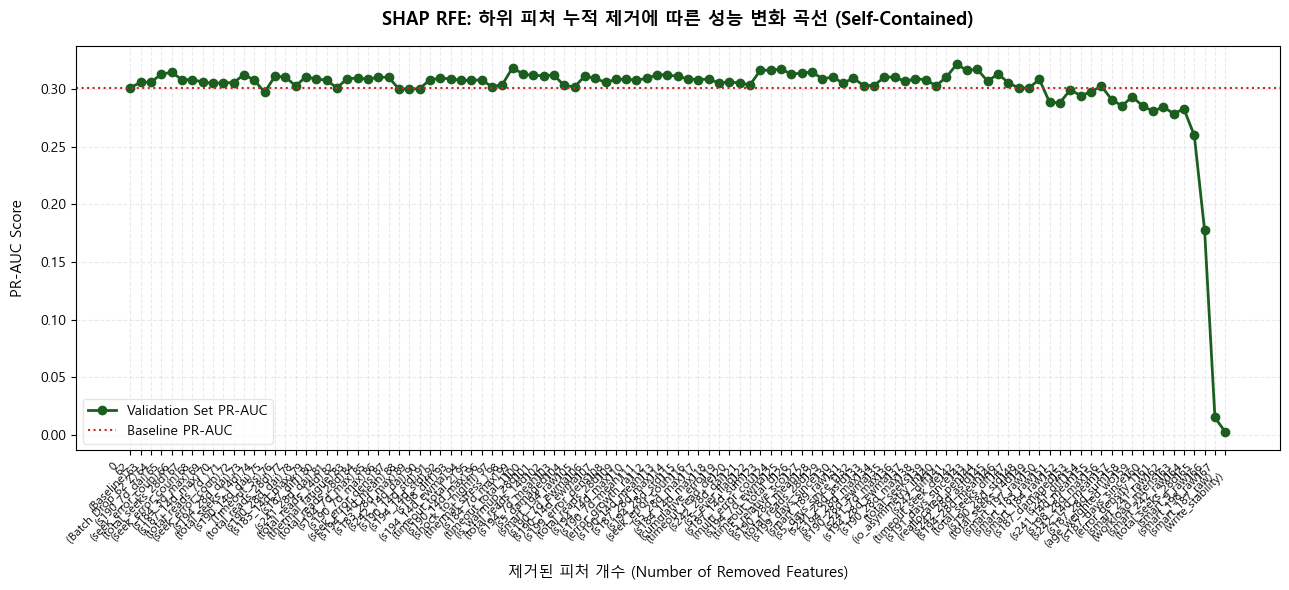

💡 [분석 팁] 그래프에서 점수가 꺾여 하락하기 직전인 지점이 성능을 보존하는 최적의 '컷오프 지점'입니다.
   위 그래프를 통해 제외할 피처 목록을 선정한 뒤 05c 노트북 시작부의 딕셔너리에 입력하세요.


In [4]:
# ── Cell 4: 제거 수에 따른 점수 변화 그래프 시각화 ────────────────
import numpy as np
plt.figure(figsize=(13, 6))

x_indices = np.arange(len(df_results))
plt.plot(x_indices, df_results["prauc"], marker='o', color='#1b5e20', linewidth=2, markersize=6, label='Validation Set PR-AUC')
plt.axhline(baseline_prauc, color='#c62828', linestyle=':', label='Baseline PR-AUC')

plt.title("SHAP RFE: 하위 피처 누적 제거에 따른 성능 변화 곡선 (Self-Contained)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("제거된 피처 개수 (Number of Removed Features)", fontsize=11, labelpad=10)
plt.ylabel("PR-AUC Score", fontsize=11, labelpad=10)

x_labels = [f"{n}\n({feat[:15]})" if n > 0 else "0\n(Baseline)" for n, feat in zip(df_results["num_removed"], df_results["removed_feature"])]
plt.xticks(x_indices, x_labels, rotation=45, ha='right', fontsize=8.5)

plt.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='#e0e0e0', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4, color='#cccccc')
plt.tight_layout()
plt.show()

print("💡 [분석 팁] 그래프에서 점수가 꺾여 하락하기 직전인 지점이 성능을 보존하는 최적의 '컷오프 지점'입니다.")
print("   위 그래프를 통해 제외할 피처 목록을 선정한 뒤 05c 노트북 시작부의 딕셔너리에 입력하세요.")


In [5]:
# ── Cell 5: 원본 데이터셋 정합성 검증 (7단계) ──────────────────────
import duckdb
con = duckdb.connect()

print("🔍 데이터셋 정합성 검증 시작...")

try:
    # 1. 파일 존재 여부 검증
    print("Validation 1: Check output files existence")
    assert os.path.exists(LocalConfig.TRAIN_PATH), f"Error: {LocalConfig.TRAIN_PATH} not found."
    assert os.path.exists(LocalConfig.VALIDATION_PATH), f"Error: {LocalConfig.VALIDATION_PATH} not found."
    print("  -> [PASS] Output files exist.")

    # 2. 날짜 컷오프 조건 검증
    print("Validation 2: Check date cutoff (>= 2014-04-01)")
    for name, path in [("TRAIN", LocalConfig.TRAIN_PATH), ("VAL", LocalConfig.VALIDATION_PATH)]:
        min_date = con.execute(f"SELECT MIN(date) FROM read_parquet('{path}')").fetchone()[0]
        min_date_str = min_date.strftime('%Y-%m-%d') if hasattr(min_date, 'strftime') else str(min_date)
        assert min_date_str >= '2014-04-01', f"Error: {name} contains date before cutoff: {min_date_str}"
    print("  -> [PASS] Date cutoff verified.")

    # 3. 피처 수 검사
    print("Validation 3: Check feature existence")
    for name, path in [("TRAIN", LocalConfig.TRAIN_PATH), ("VAL", LocalConfig.VALIDATION_PATH)]:
        cols = con.execute(f"SELECT * FROM read_parquet('{path}') WHERE 1=0").df().columns.tolist()
        assert len(cols) >= len(features), f"Error: {name} contains less columns than expected"
    print("  -> [PASS] Features verified.")

    # 4. 데이터셋 비어있지 않음 검증
    print("Validation 4: Check row count > 0")
    for name, path in [("TRAIN", LocalConfig.TRAIN_PATH), ("VAL", LocalConfig.VALIDATION_PATH)]:
        cnt = con.execute(f"SELECT COUNT(*) FROM read_parquet('{path}')").fetchone()[0]
        assert cnt > 0, f"Error: {name} is empty."
        print(f"  -> {name}: {cnt:,} rows")
    print("  -> [PASS] Output datasets are not empty.")

    # 5. Train/Validation 스키마 일치 검증
    print("Validation 5: Check schema match between Train and Validation")
    train_schema = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{LocalConfig.TRAIN_PATH}')").fetchdf()
    validation_schema = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{LocalConfig.VALIDATION_PATH}')").fetchdf()
    assert train_schema['column_name'].tolist() == validation_schema['column_name'].tolist(), "Error: column names mismatch!"
    assert train_schema['column_type'].tolist() == validation_schema['column_type'].tolist(), "Error: column types mismatch!"
    print("  -> [PASS] Train and Validation schemas are identical.")

    # 6. 결측치(NaN) 및 무한대(Inf) 잔존 여부 정밀 검증
    print("Validation 6: Check NaN/Inf values")
    for name, path in [("TRAIN", LocalConfig.TRAIN_PATH), ("VAL", LocalConfig.VALIDATION_PATH)]:
        all_cols = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{path}')").fetchdf()
        numeric_cols = [r['column_name'] for _, r in all_cols.iterrows() if r['column_name'] not in ('serial_number', 'date') and 'VARCHAR' not in r['column_type']]
        nan_checks = [f"SUM(CASE WHEN isnan(\"{nc}\") OR isinf(\"{nc}\") THEN 1 ELSE 0 END)" for nc in numeric_cols]
        if nan_checks:
            nan_results = con.execute(f"SELECT {', '.join(nan_checks)} FROM read_parquet('{path}')").fetchone()
            bad_cols = [numeric_cols[j] for j, v in enumerate(nan_results) if v and v > 0]
            assert len(bad_cols) == 0, f"Error: {name} contains NaN/Inf in columns: {bad_cols}"
    print("  -> [PASS] No NaN/Inf values found in numeric features.")

    # 7. failure 컬럼 값 범위 검증
    print("Validation 7: Check binary values in failure column")
    for name, path in [("TRAIN", LocalConfig.TRAIN_PATH), ("VAL", LocalConfig.VALIDATION_PATH)]:
        fv = con.execute(f"SELECT DISTINCT failure FROM read_parquet('{path}')").fetchall()
        fset = set(r[0] for r in fv)
        assert fset.issubset({0, 1}), f"Error: {name} failure column contains invalid values: {fset}"
    print("  -> [PASS] failure column is binary (0/1).")

    print("\nSUCCESS: All dataset verification validations passed! (7/7 PASS)")
finally:
    con.close()

🔍 데이터셋 정합성 검증 시작...
Validation 1: Check output files existence
  -> [PASS] Output files exist.
Validation 2: Check date cutoff (>= 2014-04-01)
  -> [PASS] Date cutoff verified.
Validation 3: Check feature existence
  -> [PASS] Features verified.
Validation 4: Check row count > 0
  -> TRAIN: 5,141,665 rows
  -> VAL: 1,247,377 rows
  -> [PASS] Output datasets are not empty.
Validation 5: Check schema match between Train and Validation
  -> [PASS] Train and Validation schemas are identical.
Validation 6: Check NaN/Inf values
  -> [PASS] No NaN/Inf values found in numeric features.
Validation 7: Check binary values in failure column
  -> [PASS] failure column is binary (0/1).

SUCCESS: All dataset verification validations passed! (7/7 PASS)
